In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np


In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
base_path = "../data/preprocessed/processed_data.xlsx"
df=pd.read_excel(base_path)

In [4]:
#set index
df.set_index('Date',inplace=True)

# Naive

## Hourly

In [5]:

# group data per day,month and hour 
#and reset_index to make it df
naive_hourly=df.copy()
naive_hourly=naive_hourly[naive_hourly.index.year !=2023]
naive_hourly["Hour"]=naive_hourly.index.hour
naive_hourly["Month"]=naive_hourly.index.month
naive_hourly["Day"]=naive_hourly.index.day
group_hourly=naive_hourly.groupby(["Month","Day","Hour"])['Carbon Intensity gCO₂eq/kWh (LCA)'].mean().reset_index()

#convert the grouped data to datetime
group_hourly["Date"]=pd.to_datetime({'year':2023,
                                     'Month':group_hourly['Month'],
                                     'day':group_hourly['Day'],
                                     'hour': group_hourly['Hour']})

#set date as index
group_hourly.set_index('Date',inplace=True)

#Drop the three columns created(day,month,hour)
group_hourly=group_hourly.drop(columns=['Month','Day','Hour'])


separate the 2021,2022 and 2023 datasets group hourly data

In [6]:
df_2021=df[df.index.year==2021]
df_2022=df[df.index.year==2022]
df_2023=df[df.index.year==2023]

#group hourly data for the three years
df_hourly_2021=df_2021.groupby(df_2021.index.hour)['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()
df_hourly_2022=df_2022.groupby(df_2022.index.hour)['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()
df_hourly_2023=df_2023.groupby(df_2023.index.hour)['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()


group the naive data


In [7]:
# group the naive model hourly data
model_naive_hourly=group_hourly.groupby(group_hourly.index.hour)['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()


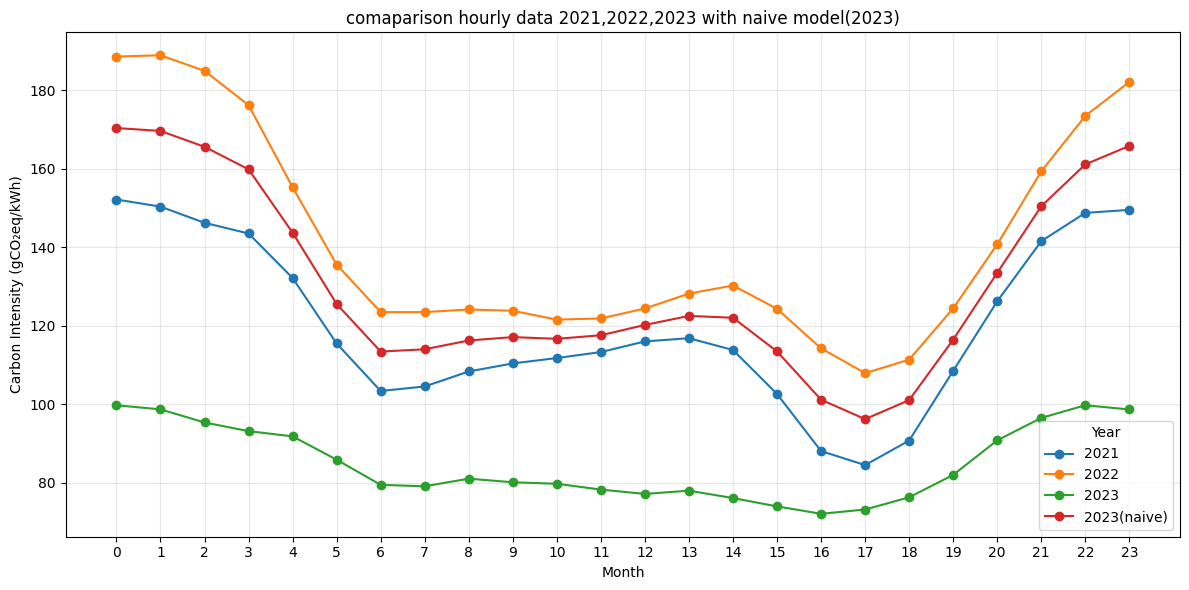

In [8]:
#plot hourly 2021,2022,2023 and compare with the naive

plt.figure(figsize=(12, 6))
plt.plot(df_hourly_2021.index,df_hourly_2021,label='2021', 
    marker='o')
plt.plot(df_hourly_2022.index,df_hourly_2022,label='2022', 
    marker='o')
plt.plot(df_hourly_2023.index,df_hourly_2023,label='2023', 
    marker='o')
plt.plot(model_naive_hourly.index,model_naive_hourly,label='2023(naive)',marker='o')

#title and labels
plt.xlabel("Month")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(range(0, 24), fontsize=10) 
plt.legend(title="Year", fontsize=10)
plt.grid(alpha=0.3)

# show
plt.title("comaparison hourly data 2021,2022,2023 with naive model(2023)")
plt.tight_layout()
plt.show()

## Monthly

In [9]:
#resample the naive model to monthly
model_naive_monthly=group_hourly.resample("ME").mean()


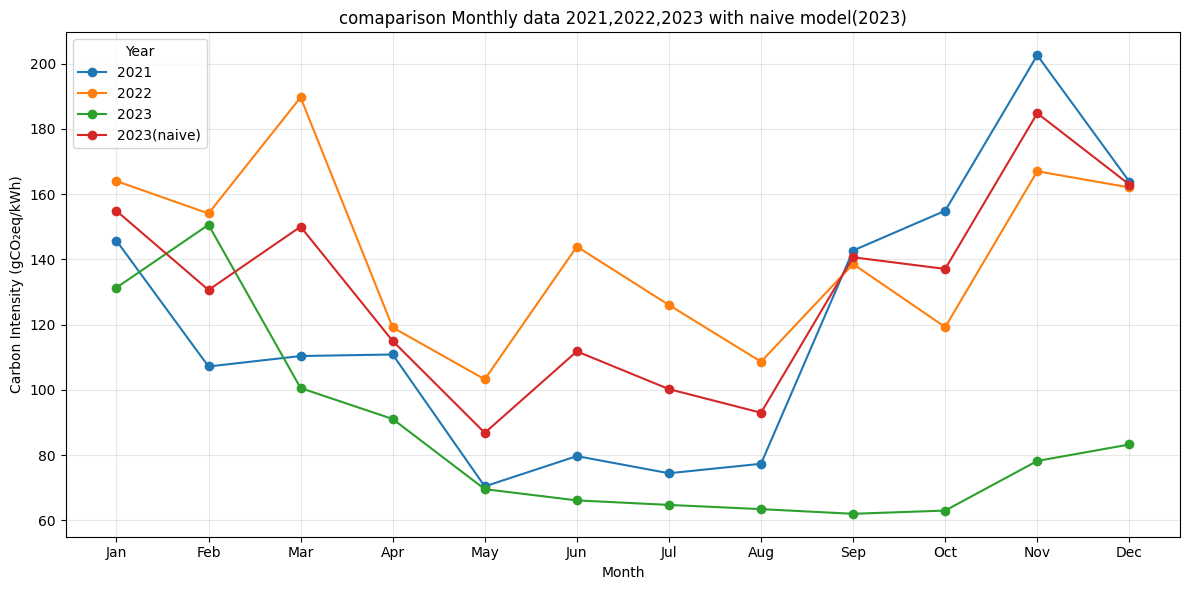

In [10]:
# plot the naive model and the grouped data for 2021,2022,2023

df_2021=df_2021.resample("ME").mean()
df_2022=df_2022.resample("ME").mean()
df_2023=df_2023.resample("ME").mean()

plt.figure(figsize=(12, 6))
plt.plot(df_2021.index.month,df_2021['Carbon Intensity gCO₂eq/kWh (LCA)'],label='2021', 
    marker='o')
plt.plot(df_2022.index.month,df_2022['Carbon Intensity gCO₂eq/kWh (LCA)'],label='2022', 
    marker='o')
plt.plot(df_2023.index.month,df_2023['Carbon Intensity gCO₂eq/kWh (LCA)'],label='2023', 
    marker='o')
plt.plot(model_naive_monthly.index.month,model_naive_monthly, label='2023(naive)', 
    marker='o')

plt.xlabel("Month")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(range(1, 13), [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=10)
plt.legend(title="Year", fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.title("comaparison Monthly data 2021,2022,2023 with naive model(2023)")
plt.tight_layout()
plt.show()


## metrics

In [11]:

mae_naive=mean_absolute_error(df_2023['Carbon Intensity gCO₂eq/kWh (LCA)'],model_naive_monthly['Carbon Intensity gCO₂eq/kWh (LCA)'])
mse_naive=mean_squared_error(df_2023['Carbon Intensity gCO₂eq/kWh (LCA)'],model_naive_monthly['Carbon Intensity gCO₂eq/kWh (LCA)'])
rmse_naive=np.sqrt(mse_naive)
mape_naive=np.mean(np.abs(df_2023-model_naive_monthly['Carbon Intensity gCO₂eq/kWh (LCA)'])/df_2023['Carbon Intensity gCO₂eq/kWh (LCA)']) * 100

print("\nThe metrics for the Naive model")
print()
print(f"mean absolute error :  {mae_naive}")
print(f"mean squared error :  {mse_naive}")
print(f"Root mean squared error :  {rmse_naive}")

print(f"mean absolute percentage error :  {mape_naive}")



The metrics for the Naive model

mean absolute error :  48.683966696535244
mean squared error :  3159.550653885817
Root mean squared error :  56.20988039380459
mean absolute percentage error :  nan


# Compare naive with a trained early model

In [12]:
monthly_data=df.copy()
monthly_data=monthly_data.resample('ME').mean()
monthly_data['Low Carbon Percentage']=monthly_data['Low Carbon Percentage']/100
monthly_data['Renewable Percentage']=monthly_data['Renewable Percentage']/100

In [13]:
#split data

train_data=monthly_data['2021':'2022']
test_data=monthly_data['2023':]
#exogeneous variables
exog_train = train_data[['Total energy production Swiss controlblock(KWH)',
                         'Total energy consumption Swiss controlblock(KWH)',
                         'Renewable Percentage',
                         'Low Carbon Percentage'
                        ]
                         ]

exog_test = test_data[['Total energy production Swiss controlblock(KWH)',
                       'Total energy consumption Swiss controlblock(KWH)',
                       'Renewable Percentage',
                       'Low Carbon Percentage'
                       ]]
#Target Variable
y_train = train_data['Carbon Intensity gCO₂eq/kWh (LCA)']  # Target variable for training
y_test = test_data['Carbon Intensity gCO₂eq/kWh (LCA)']

In [14]:

#define SARIMA parameters for monthly data
sarima_order_monthly=(0,0,1)
seasonal_order_monthly=(0,1,0,12)

#fit the model
sarima_monthly_model=SARIMAX(
    y_train,
    exog=exog_train,
    order=sarima_order_monthly,
    seasonal_order=seasonal_order_monthly,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=5000,method='powell' )


In [15]:
#predict
predict=sarima_monthly_model.forecast(steps=len(y_test),exog=exog_test)


In [16]:
print(y_test.shape)
print(predict.shape)

(12,)
(12,)


In [17]:
#evaluate
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
mae=mean_absolute_error(y_test,predict)
mse=mean_squared_error(y_test,predict)
rmse=np.sqrt(mse)
mape=np.mean(np.abs(y_test-predict)/y_test) * 100

print("\nThe metrics for the Sarima model")
print()
print(f"mean absolute error :  {mae}")
print(f"mean squared error :  {mse}")
print(f"Root mean squared error :  {rmse}")

print(f"mean absolute percentage error :  {mape}")


The metrics for the Sarima model

mean absolute error :  11.745809679475096
mean squared error :  167.78689295542907
Root mean squared error :  12.953258005437437
mean absolute percentage error :  16.023629950263736


In [18]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Forecast': predict,
    'difference':abs(y_test-predict)
})
comparison

,Actual,Forecast,difference
2023-01-31,131.339073,128.024521,3.314552
2023-02-28,150.613765,152.254265,1.640500
2023-03-31,100.541398,88.245588,12.295810
2023-04-30,91.049694,84.692945,6.356750
2023-05-31,69.528952,53.770953,15.757999
2023-06-30,66.086639,50.834160,15.252479
2023-07-31,64.695349,52.119583,12.575767
2023-08-31,63.406142,46.547572,16.858571
2023-09-30,61.974389,51.439159,10.535230
2023-10-31,62.964355,53.647615,9.316740


### plot actual,naive and early model monthly 

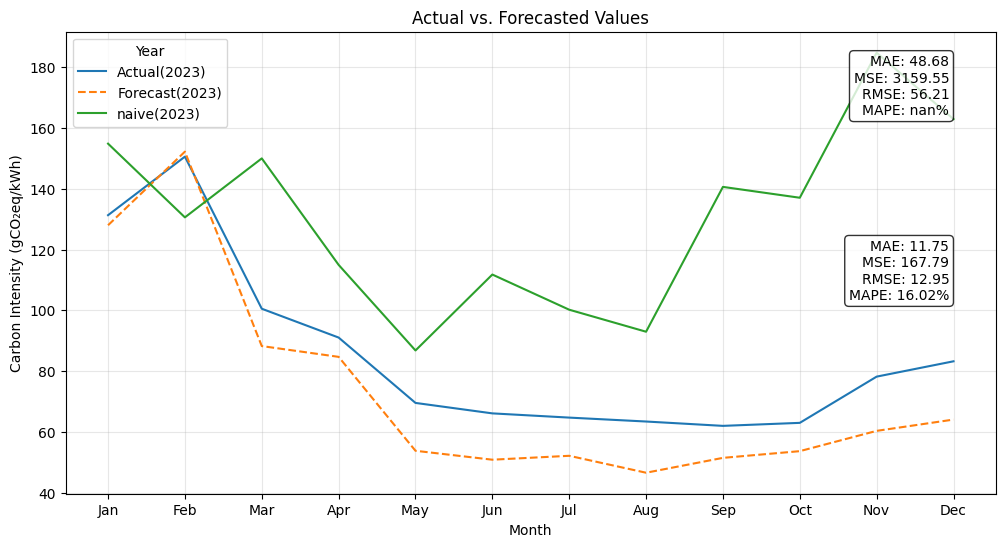

In [19]:


plt.figure(figsize=(12, 6))
plt.plot(y_test.index.month,y_test, label='Actual(2023)')
plt.plot(y_test.index.month,predict, label='Forecast(2023)', linestyle='--')
plt.plot(model_naive_monthly.index.month,model_naive_monthly,label="naive(2023)")
#title and label
plt.xlabel("Month")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.xticks(range(1, 13), [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=10)
plt.legend(title="Year", fontsize=10)
plt.grid(alpha=0.3)
plt.title('Actual vs. Forecasted Values')

#metrics
metrics_text_naive = (
    f"MAE: {mae_naive:.2f}\n"
    f"MSE: {mse_naive:.2f}\n"
    f"RMSE: {rmse_naive:.2f}\n"
    f"MAPE: {mape_naive:.2f}%"
)
plt.text(
    0.95, 0.95, metrics_text_naive, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

metrics_text_predicted = (
    f"MAE: {mae:.2f}\n"
    f"MSE: {mse:.2f}\n"
    f"RMSE: {rmse:.2f}\n"
    f"MAPE: {mape:.2f}%"
)
plt.text(
    0.95, 0.55, metrics_text_predicted, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.show()


# Write naive hourly to a file

In [20]:
# write
group_hourly.to_csv("../data/models/naive_data1.csv",index=True)